# ET Noise Budget Curves with 10km, 15km, 20km arm length

These are plots of the noise budget curves and examples on how to work with them.

To plot these curves yourself, you will need:

* an up-to-date python installation (e.g. Anaconda)
* pygwinc (`pip install gwinc`)

In [1]:
import matplotlib.pyplot as plt
import gwinc
import numpy as np
from gwinc.ifo.noises import arm_cavity
from  ETLF import sqz_dual_fc
from  ETHF  import squeezingFC
%matplotlib inline

# ET High-Frequency

In [2]:
freq=np.logspace(0,4,3000)

## 10km HF

In [3]:
budgetHF = gwinc.load_budget('ETHF',freq=freq)
tracesHF = budgetHF.run()
#fig = gwinc.plot_budget(tracesHF)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.xlim([5, 1e4])
#plt.ylim([5e-26, 1e-22])

## 15km HF，12cm beam size，200kg

In [4]:
budgetHF15kmA = gwinc.load_budget('ETHF',freq=freq)
budgetHF15kmA.ifo.Infrastructure.Length=15000
budgetHF15kmA.ifo.Optics.Curvature.ITM=7750
budgetHF15kmA.ifo.Optics.Curvature.ETM=7750
budgetHF15kmA.ifo.Optics.SRM.Transmittance=0.07
budgetHF15kmA.ifo.Squeezer.FilterCavity=squeezingFC.computeFCParams(budgetHF15kmA.ifo)
tracesHF15kmA = budgetHF15kmA.run()
#fig = gwinc.plot_budget(tracesHF15kmA)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.ylim([5e-26, 1e-22])

In [5]:
print('Filter cavity input mirror T={}'.format(format(budgetHF15kmA.ifo.Squeezer.FilterCavity.Ti,".6f")),
      'Filter cavity input mirror Detune={}'.format(format(budgetHF15kmA.ifo.Squeezer.FilterCavity.fdetune,".6f")),sep="\n")

Filter cavity input mirror T=0.000637
Filter cavity input mirror Detune=-25.233814


## 15km HF，13.5cm beam size，200kg

In [6]:
budgetHF15kmB = gwinc.load_budget('ETHF',freq=freq)
budgetHF15kmB.ifo.Infrastructure.Length=15000
budgetHF15kmB.ifo.Optics.Curvature.ITM=7650
budgetHF15kmB.ifo.Optics.Curvature.ETM=7650
budgetHF15kmB.ifo.Optics.SRM.Transmittance=0.07
budgetHF15kmB.ifo.Materials.MassRadius=0.68/2
budgetHF15kmB.ifo.Materials.MassThickness=0.25
budgetHF15kmB.ifo.Squeezer.FilterCavity=squeezingFC.computeFCParams(budgetHF15kmB.ifo)
tracesHF15kmB = budgetHF15kmB.run()
#fig = gwinc.plot_budget(tracesHF15kmB)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.ylim([5e-26, 1e-22]) 

In [7]:
#arm_cavity(budgetHF15kmB.ifo).wBeam_ITM

## 20km HF，12cm beam size，200kg

In [8]:
budgetHF20kmA = gwinc.load_budget('ETHF',freq=freq)
budgetHF20kmA.ifo.Infrastructure.Length=20000
budgetHF20kmA.ifo.Optics.Curvature.ITM=10620
budgetHF20kmA.ifo.Optics.Curvature.ETM=10620
budgetHF20kmA.ifo.Optics.SRM.Transmittance=0.05
budgetHF20kmA.ifo.Squeezer.FilterCavity=squeezingFC.computeFCParams(budgetHF20kmA.ifo)
tracesHF20kmA = budgetHF20kmA.run()
#fig = gwinc.plot_budget(tracesHF20kmA)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.ylim([5e-26, 1e-22])

In [9]:
print('Filter cavity input mirror T={}'.format(format(budgetHF20kmA.ifo.Squeezer.FilterCavity.Ti,".6f")),
      'Filter cavity input mirror Detune={}'.format(format(budgetHF20kmA.ifo.Squeezer.FilterCavity.fdetune,".6f")),sep="\n")

Filter cavity input mirror T=0.000536
Filter cavity input mirror Detune=-21.195505


## 20km HF，15cm beam size，200kg

In [10]:
budgetHF20kmB = gwinc.load_budget('ETHF',freq=freq)
budgetHF20kmB.ifo.Infrastructure.Length=20000
budgetHF20kmB.ifo.Optics.Curvature.ITM=10240
budgetHF20kmB.ifo.Optics.Curvature.ETM=10240
budgetHF20kmB.ifo.Materials.MassRadius=0.75/2
budgetHF20kmB.ifo.Materials.MassThickness=0.21
budgetHF20kmB.ifo.Optics.SRM.Transmittance=0.05
budgetHF20kmB.ifo.Squeezer.FilterCavity=squeezingFC.computeFCParams(budgetHF20kmB.ifo)
tracesHF20kmB = budgetHF20kmB.run()
#fig = gwinc.plot_budget(tracesHF20kmB)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.ylim([5e-26, 1e-22])

# ET Low-Frequency

## 10km LF

In [11]:
budgetLF = gwinc.load_budget('ETLF',freq=freq)
budgetLF.ifo.Squeezer.FilterCavity=sqz_dual_fc.computeFCParams(budgetLF.ifo)
tracesLF = budgetLF.run()
#fig = gwinc.plot_budget(tracesLF)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.legend(loc='upper right')
#plt.ylim([5e-26, 1e-21])

In [12]:
print('Filter cavity 1 input mirror T={}'.format(format(budgetLF.ifo.Squeezer.FilterCavity[0].Ti,".6f")),
      'Filter cavity 1 input mirror Detune={}'.format(format(budgetLF.ifo.Squeezer.FilterCavity[0].fdetune,".6f")),
      'Filter cavity 2 input mirror T={}'.format(format(budgetLF.ifo.Squeezer.FilterCavity[1].Ti,".6f")),
      'Filter cavity 2 input mirror Detune={}'.format(format(budgetLF.ifo.Squeezer.FilterCavity[1].fdetune,".6f")),sep="\n")

Filter cavity 1 input mirror T=0.000127
Filter cavity 1 input mirror Detune=-6.882666
Filter cavity 2 input mirror T=0.000480
Filter cavity 2 input mirror Detune=25.305748


## 15km LF, 9cm beam size

In [13]:
budgetLF15kmA = gwinc.load_budget('ETLF',freq=freq)
budgetLF15kmA.ifo.Optics.SRM.Transmittance=0.14
budgetLF15kmA.ifo.Optics.SRM.Tunephase=0.4
budgetLF15kmA.ifo.Infrastructure.Length=15000
budgetLF15kmA.ifo.Optics.Curvature.ITM=10670
budgetLF15kmA.ifo.Optics.Curvature.ETM=10670
budgetLF15kmA.ifo.Squeezer.FilterCavity=sqz_dual_fc.computeFCParams(budgetLF15kmA.ifo)
tracesLF15kmA = budgetLF15kmA.run()
#fig = gwinc.plot_budget(tracesLF15kmA)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.legend(loc='upper right')
#plt.ylim([5e-26, 1e-21])

In [14]:
print('Filter cavity 1 input mirror T={}'.format(format(budgetLF15kmA.ifo.Squeezer.FilterCavity[0].Ti,".6f")),
      'Filter cavity 1 input mirror Detune={}'.format(format(budgetLF15kmA.ifo.Squeezer.FilterCavity[0].fdetune,".6f")),
      'Filter cavity 2 input mirror T={}'.format(format(budgetLF15kmA.ifo.Squeezer.FilterCavity[1].Ti,".6f")),
      'Filter cavity 2 input mirror Detune={}'.format(format(budgetLF15kmA.ifo.Squeezer.FilterCavity[1].fdetune,".6f")),sep="\n")

Filter cavity 1 input mirror T=0.000095
Filter cavity 1 input mirror Detune=-5.550920
Filter cavity 2 input mirror T=0.000459
Filter cavity 2 input mirror Detune=26.011917


## 20km LF, 10 cm beam size, 45cm mirror

In [15]:
budgetLF20kmA = gwinc.load_budget('ETLF',freq=freq)
budgetLF20kmA.ifo.Optics.PRM.Transmittance=0.08
budgetLF20kmA.ifo.Optics.SRM.Transmittance=0.105
budgetLF20kmA.ifo.Optics.SRM.Tunephase=0.3
budgetLF20kmA.ifo.Infrastructure.Length=20000
budgetLF20kmA.ifo.Optics.Curvature.ITM=16000
budgetLF20kmA.ifo.Optics.Curvature.ETM=16000
budgetLF20kmA.ifo.Optics.Loss=73e-6
budgetLF20kmA.ifo.Squeezer.FilterCavity=sqz_dual_fc.computeFCParams(budgetLF20kmA.ifo)
tracesLF20kmA = budgetLF20kmA.run()
#fig = gwinc.plot_budget(tracesLF20kmA)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.legend(loc='upper right')
#plt.ylim([5e-26, 1e-21])

In [16]:
print('Filter cavity 1 input mirror T={}'.format(format(budgetLF20kmA.ifo.Squeezer.FilterCavity[0].Ti,".6f")),
      'Filter cavity 1 input mirror Detune={}'.format(format(budgetLF20kmA.ifo.Squeezer.FilterCavity[0].fdetune,".6f")),
      'Filter cavity 2 input mirror T={}'.format(format(budgetLF20kmA.ifo.Squeezer.FilterCavity[1].Ti,".6f")),
      'Filter cavity 2 input mirror Detune={}'.format(format(budgetLF20kmA.ifo.Squeezer.FilterCavity[1].fdetune,".6f")),sep="\n")

Filter cavity 1 input mirror T=0.000055
Filter cavity 1 input mirror Detune=-3.480377
Filter cavity 2 input mirror T=0.000431
Filter cavity 2 input mirror Detune=26.507715


## 20km LF, 10 cm beam size, 45cm mirror, 5.6W input power   

In [17]:
budgetLF20kmB = gwinc.load_budget('ETLF',freq=freq)
budgetLF20kmB.ifo.Laser.Power=5.6
budgetLF20kmB.ifo.Optics.PRM.Transmittance=0.08
budgetLF20kmB.ifo.Optics.SRM.Transmittance=0.105
budgetLF20kmB.ifo.Optics.SRM.Tunephase=0.3
budgetLF20kmB.ifo.Infrastructure.Length=20000
budgetLF20kmB.ifo.Optics.Curvature.ITM=16000
budgetLF20kmB.ifo.Optics.Curvature.ETM=16000
budgetLF20kmB.ifo.Optics.Loss=73e-6
budgetLF20kmB.ifo.Squeezer.FilterCavity=sqz_dual_fc.computeFCParams(budgetLF20kmB.ifo)
tracesLF20kmB = budgetLF20kmB.run()
#fig = gwinc.plot_budget(tracesLF20kmB)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.legend(loc='upper right')
#plt.ylim([5e-26, 1e-21])

## 20km LF, 10 cm beam size, 50cm mirror

In [18]:
budgetLF20kmC = gwinc.load_budget('ETLF',freq=freq)
budgetLF20kmC.ifo.Optics.SRM.Transmittance=0.105
budgetLF20kmC.ifo.Optics.SRM.Tunephase=0.3
budgetLF20kmC.ifo.Infrastructure.Length=20000
budgetLF20kmC.ifo.Optics.Curvature.ITM=16000
budgetLF20kmC.ifo.Optics.Curvature.ETM=16000
budgetLF20kmC.ifo.Materials.MassRadius=0.25
budgetLF20kmC.ifo.Materials.MassThickness=0.21
budgetLF20kmC.ifo.Squeezer.FilterCavity=sqz_dual_fc.computeFCParams(budgetLF20kmC.ifo)
tracesLF20kmC = budgetLF20kmC.run()
#fig = gwinc.plot_budget(tracesLF20kmL)
#plt.ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
#plt.legend(loc='upper right')
#plt.ylim([5e-26, 1e-21])

In [19]:
ET10km=1/(1/tracesLF.psd+1/tracesHF.psd)
ET15km=1/(1/tracesLF15kmA.psd+1/tracesHF15kmA.psd)
ET20km=1/(1/tracesLF20kmA.psd+1/tracesHF20kmA.psd)
ET1520km=1/(1/tracesLF15kmA.psd+1/tracesHF20kmA.psd)
ET20kmB=1/(1/tracesLF20kmB.psd+1/tracesHF20kmA.psd)
ET20kmC=1/(1/tracesLF20kmC.psd+1/tracesHF20kmA.psd)

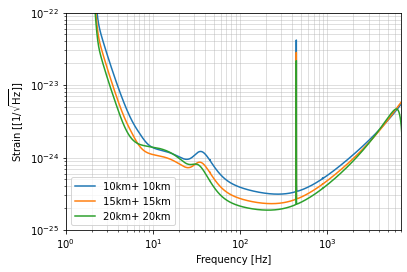

In [20]:
fig=plt.figure(figsize=(6., 4.))
ax=fig.add_subplot(111)
ax.loglog(freq,np.sqrt(ET10km),label='10km+ 10km')
ax.loglog(freq,np.sqrt(ET15km),label='15km+ 15km')
ax.loglog(freq,np.sqrt(ET20km),label='20km+ 20km')
ax.legend()
ax.set_xlim([1,7000])
ax.set_ylim([1e-25, 1e-22])
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
ax.grid(True,which='both',alpha=0.5)
#plt.savefig("ET290K.pdf",bbox_inches='tight')

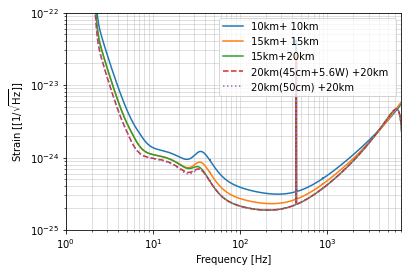

In [21]:
fig=plt.figure(figsize=(6., 4.))
ax=fig.add_subplot(111)
ax.loglog(freq,np.sqrt(ET10km),label='10km+ 10km')
ax.loglog(freq,np.sqrt(ET15km),label='15km+ 15km')
ax.loglog(freq,np.sqrt(ET1520km),label='15km+20km')
ax.loglog(freq,np.sqrt(ET20kmB),'--',label='20km(45cm+5.6W) +20km ')
ax.loglog(freq,np.sqrt(ET20kmC),':',label='20km(50cm) +20km ')
ax.legend()
ax.set_xlim([1,7000])
ax.set_ylim([1e-25, 1e-22])
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain [[$1 / \sqrt{\mathrm{Hz}}$]]')
ax.grid(True,which='both',alpha=0.5)
#plt.savefig("ET290K.pdf",bbox_inches='tight') 